# Red tides data

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/aselshall/eds/HEAD)

---

In [1]:
import numpy as np
import pandas as pd

import os
from pathlib import Path
from scipy.io import loadmat  # this is the SciPy module that loads mat-files

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import warnings
warnings.filterwarnings("ignore", message="facecolor will have no effect as it has been defined as \"never\"")

## 1. Red tide data for study area

Data download: https://www.ncei.noaa.gov/archive/archive-management-system/OAS/bin/prd/jquery/accession/details/120767

Direct access to current dataset (habsos_20240430): https://www.ncei.noaa.gov/data/oceans/archive/arc0069/0120767/8.8/data/0-data/

Data documentation: https://www.ncei.noaa.gov/data/oceans/archive/arc0069/0120767/8.8/data/0-data/Support%20Documents/AL%20Data%20Documentation%202016.pdf

In [2]:
# Read a csv file with Pandas
df = pd.read_csv('input/habsos_20240430.csv', low_memory=False)

# Select column names that you need for your analysis (e.g., 'LATITUDE', 'LONGITUDE', 'SAMPLE_DATE', 'CELLCOUNT', etc.) 
selected_columns = ['STATE_ID','DESCRIPTION','LATITUDE', 'LONGITUDE', 'SAMPLE_DATE', 'CELLCOUNT',
                   'SALINITY','WATER_TEMP','WIND_DIR','WIND_SPEED']

# Filter the DataFrame to include only the selected columns
df = df[selected_columns]

# Display your DataFrame
df

# Create a new column 'region' with default value 'Other'
df['REGION'] = 'Other'

# Mask for dicing: Define mask for Tampa Bay region based on latitude and longitude values
tampa_bay_mask = (df['LATITUDE'] >= 27) & (df['LATITUDE'] <= 28) & (df['LONGITUDE'] >= -85)

# Assign value 'Tampa Bay' to rows matching Tampa Bay mask 
df.loc[tampa_bay_mask, 'REGION'] = 'Tampa Bay'

# Mask for decing: Define mask for Charlotte Harbor estuary region  based on latitude and longitude values
charlotte_harbor_mask = (df['LATITUDE'] >= 25.5) & (df['LATITUDE'] < 27) & (df['LONGITUDE'] >= -85)

# Assign value 'Charlotte Harbor' to rows matching Charlotte Harbor mask
df.loc[charlotte_harbor_mask, 'REGION'] = 'Charlotte Harbor'

#Display dataframe
df

,STATE_ID,DESCRIPTION,LATITUDE,LONGITUDE,SAMPLE_DATE,CELLCOUNT,SALINITY,WATER_TEMP,WIND_DIR,WIND_SPEED,REGION
0,TX,Copano Bay 4,28.07237,-97.21968,2023/09/27,0,NaN,NaN,NaN,NaN,Other
1,TX,Copano Bay 2,27.99567,-97.16831,2023/09/27,0,NaN,NaN,NaN,NaN,Other
2,TX,Copano Bay 3,28.03930,-97.15836,2023/09/27,0,NaN,NaN,NaN,NaN,Other
3,TX,Copano Bay 1,28.06491,-97.11270,2023/09/27,0,NaN,NaN,NaN,NaN,Other
4,FL,off New Smyrna Beach; Atlantic,29.17460,-78.27890,1990/12/20,0,NaN,24.2,NaN,NaN,Other
...,...,...,...,...,...,...,...,...,...,...,...
211829,TX,"Nueces Bay, East of Nueces River Delta",27.86611,-97.51636,2015/10/14,0,NaN,NaN,NaN,NaN,Other
211830,TX,Viola Turning Basin (Sample ID 1230-1),27.84455,-97.52228,2009/12/30,1000000,NaN,NaN,NaN,NaN,Other
211831,TX,"South Padre Island, Brazos Santiago Pass south...",26.18451,-97.66535,2015/09/25,922000,34.0,29.0,NaN,NaN,Other
211832,TX,"South Padre Island, Brazos Santiago Pass south...",26.18451,-97.66535,2015/10/02,1513000,NaN,NaN,NaN,NaN,Other


## 2. Plot red tides

### 2.1 Bathymetry data

In [3]:
#[1] Load zos data 
member='AVISO-1-1_phy-001-030_r0'

#[2] Load Bathymetry_AVISO data
#Bathymetry=['NOAA','B-50','B-300','B-1000','B-2000','B-3000']
Bathymetry=['B300']
for bathymetry in Bathymetry: 
    yx=np.loadtxt('input/DigitizeSegments_Bathymetry_AVISO_{}.csv'.format(bathymetry),delimiter=',')
    print(yx.shape)
    
# Create coordinates for the four labels
latitudes= yx[:,0]  # latitude values 
longitudes= yx[:,1]  # longitude values 

(119, 2)


In [4]:
##### [1] Display processed results
#Section information (KB_Data_ESM)
#m=loadmat('zos_data_B300/Optimization/R3210.mat')
m=loadmat('input/zos_data_B300_segments.mat')

ndata = {n: m['row'][n][0,0] for n in m['row'].dtype.names}
dfm=pd.DataFrame.from_dict(dict((column, ndata[column][0]) for column in [n for n, v in ndata.items() if v.size == 1]))
#display(dfm)

#display(dfm)
NSeg=dfm['N'][0]; ns=dfm['Nstr'][0]; ne=dfm['Nend'][0];SSeg=dfm['S'][0]; ss=dfm['Sstr'][0]; se=dfm['Send'][0];
print('{} ({},{}) and {} ({},{}) north and south segments with {} and {} cells, respectively'.format(NSeg,ns,ne,SSeg,ss,se,ne-ns+1,se-ss+1))


B-300 (9,22) and B-300 (59,78) north and south segments with 14 and 20 cells, respectively


### 2.2 Convert lat and lon degree to decimal  

In [5]:
# Function to convert DMS to decimal degrees
def dms_to_decimal(degrees, minutes, seconds, direction):
    decimal = degrees + minutes / 60 + seconds / 3600
    if direction in ['S', 'W']:
        decimal = -decimal
    return decimal

# Input values
lat_dms = (25, 42, 1, 'N')
lon_dms = (83, 38, 28, 'W')

# Convert to decimal degrees
lat_decimal = dms_to_decimal(*lat_dms)
lon_decimal = dms_to_decimal(*lon_dms)

print(f"Latitude: {lat_decimal:.6f}, Longitude: {lon_decimal:.6f}")

Latitude: 25.700278, Longitude: -83.641111


### 2.3 Plot study area


 Plot saved to: figures/plot_output.png


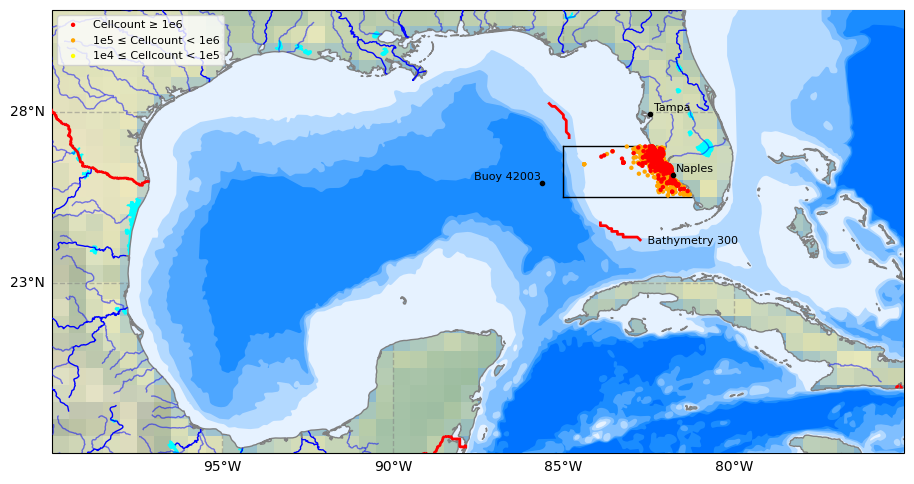

In [6]:
# 0) Select data to plot
Plot_Num= 2  #Type 1 to plot SLA data for the first time step or 2 to plot bathymetry lines

# 1) Select plot extend: Lon_West, Lon_East, Lat_South, Lat_North in Degrees
extent = [-75, -100, 18, 31] #Gulf of Mexico
#extent = [-80, -100, 20, 31] 

# 2) Select projection
projPC = ccrs.PlateCarree()

# 3) Create figure
fig = plt.figure(figsize=(11, 8.5))
#plt.subplots_adjust(hspace=0.1, wspace=0.2)  # Adjust the height and width spaces between subplots

# 4) Loop to plot variables 
variable = 'sla'
colormap = 'coolwarm'
title=''

# 5) Create Axes     
ax = plt.subplot(1, 1, 1, projection=projPC)

# 6) Setting the extent of the plot
ax.set_extent(extent, crs=projPC)

# 7) Add plot title 
ax.set_title(title, fontsize=10, loc='left')

# 8) Add gridlines (we need to cutomize grid lines to improve visualization)                              
gl = ax.gridlines(draw_labels=True, xlocs=np.arange(extent[1],extent[0], 5), ylocs= np.arange(extent[2], extent[3], 5),
                  linewidth=1, color='gray', alpha=0.5, linestyle='--',  zorder=40)

gl.right_labels = False  # 
gl.top_labels = False    # Set the font size for x-axis labels
gl.xlabel_style = {'size': 10}  # Set the font size for x-axis labels
gl.ylabel_style = {'size': 10}  # Set the font size for y-axis labels

# 9) Adding Natural Earth features
## Pre-defined features
ax.set_facecolor(cfeature.COLORS['water'])  #Blackgroundwater color for the ocean
#ax.add_feature(cfeature.LAND.with_scale('10m'), zorder=20) 
ax.add_feature(cfeature.LAKES.with_scale('10m'), color='aqua', zorder=21) 
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), color='gray', zorder=21) 
ax.add_feature(cfeature.BORDERS, edgecolor='red',facecolor='none', linewidth=2, zorder=22) 
ax.stock_img()

## General features (not pre-defined)
ax.add_feature(cfeature.NaturalEarthFeature(
    'physical', 'rivers_lake_centerlines', scale='10m', edgecolor='blue', facecolor='none') ,zorder=21)
ax.add_feature(cfeature.NaturalEarthFeature(
    'physical','rivers_north_america', scale='10m', edgecolor='blue', facecolor='none', alpha=0.5),zorder=21)

# 10) Adding user-defined features 
# Plot site area on GeoAxes given lon and lat coordinates in first subplot 
#ax.plot([-85.0, -85.0], [27, 28.0], color='black', linewidth=1, zorder = 15)    #Tampa Bay region
ax.plot([-85.0, -85.0], [25.5, 27.0], color='black', linewidth=1, zorder = 15)  # Charlotte Harbor est uary region 
#ax.plot([-85.0, -82.85], [28.0, 28.0], color='black', linewidth=1, zorder = 15)
ax.plot([-85.0, -82.4], [27, 27], color='black', linewidth=1, zorder = 15)
ax.plot([-85.0, -81.2], [25.5, 25.5], color='black', linewidth=1, zorder = 15)


## 11) Plot Track 026 line on GeoAxex and annotate with text using axes cooridnates in second subplot
#points = np.array([[-85.7940, 28.4487], [-83.6190, 23.8411]]) 
#ax.plot(longitudes, latitudes, color='black', linewidth=2, zorder = 15)
ax.plot(longitudes[ns:ne], latitudes[ns:ne], color='red', linewidth=2, zorder = 15)
ax.plot(longitudes[ss:se], latitudes[ss:se], color='red', linewidth=2, zorder = 15)
ax.text(0.75, 0.48, ' Bathymetry 300', transform=ax.transAxes,   #x,y 
        color='black', fontsize=8,  ha='center',  va='center',  rotation=0, zorder = 15)

## Adding names and locations of major cities
locations_coordinates = {"Tampa": [27.9506, -82.4572], 
                     #"Sarasota": [27.3364, -82.5307], 
                     #"Fort Myers": [26.6406, -81.8723], 
                     "Naples": [26.142, -81.7948],  
                        }
for location, coordinates in locations_coordinates.items():
    ax.plot(coordinates[1], coordinates[0],  
            transform=ccrs.PlateCarree(),  marker='o', color='black', markersize=3, zorder = 28)
    ax.text(coordinates[1] + 0.1, coordinates[0] + 0.1, 
            location, transform=ccrs.PlateCarree(), color='black', fontsize=8, zorder = 28)

locations_coordinates = {
                     "Buoy 42003": [25.9253, -85.6161],
                    #"Buoy 42097": [25.700278, -83.641111]
                        }
for location, coordinates in locations_coordinates.items():
    ax.plot(coordinates[1], coordinates[0],  
            transform=ccrs.PlateCarree(),  marker='o', color='black', markersize=3, zorder = 22)
    ax.text(coordinates[1] - 2, coordinates[0] + 0.1, 
            location, transform=ccrs.PlateCarree(), color='black', fontsize=8, zorder = 22)


# 11) Adding raster data and colorbar for the first three subplots
if Plot_Num ==1:
    # dataplot = ax.contourf(da.latitude, da.longitude, da.sla[0,:,:], 
    #                        cmap=colormap, zorder=12, transform=ccrs.PlateCarree())
    dataplot = ax.contourf(ds.longitude, ds.latitude, ds.sla[0,:,:], 
                           cmap=colormap, zorder=12, transform=ccrs.PlateCarree())
    colorbar = plt.colorbar(dataplot, orientation='horizontal', pad=0.1, shrink=1)  
    colorbar.set_label(ds.sla.attrs['standard_name'], fontsize=10)

#12) Plot 6 bathymetry lines using a loop
if Plot_Num == 2:
    # Names of bathymetry line 
    bathymetry_names = ['bathymetry_L_0', 'bathymetry_K_200', 
                        'bathymetry_J_1000', 'bathymetry_I_2000', 
                        'bathymetry_H_3000', 'bathymetry_G_4000'] 
    
    # Very light blue to light blue generated by ChatGPT 3.5 Turbo
    colors = [(0.9, 0.95, 1), (0.7, 0.85, 1), 
              (0.5, 0.75, 1), (0.3, 0.65, 1), 
              (0.1, 0.55, 1), (0, 0.45, 1), ]  
    
    # Loop to plot each bathymetry line
    for bathymetry_name, color in zip(bathymetry_names, colors):
        ax.add_feature(
            cfeature.NaturalEarthFeature(
                category='physical', 
                name=bathymetry_name, 
                scale='10m', 
                edgecolor='none', 
                facecolor=color
            ), 
            zorder = 11)


# Plot red dots for CELLCOUNT >= 1e6 in the 'Charlotte Harbor' region with SAMPLE_DATE >= 1992-01-01
charlotte_harbor = df[
    (df['CELLCOUNT'] >= 1e5) & 
    (df['REGION'] == 'Charlotte Harbor') & 
    (df['LONGITUDE'] <= -81) & 
    (pd.to_datetime(df['SAMPLE_DATE']) >= pd.to_datetime('1992-01-01'))
]

# Plot red dots for CELLCOUNT >= 1e6
high = charlotte_harbor[charlotte_harbor['CELLCOUNT'] >= 1e6]
sc_high = ax.scatter(high['LONGITUDE'], high['LATITUDE'], 
                     color='red', s=10, edgecolor='none',
                     transform=ccrs.PlateCarree(), zorder=25)

# Plot orange dots for 1e5 <= CELLCOUNT < 1e6
medium = charlotte_harbor[(charlotte_harbor['CELLCOUNT'] >= 1e5) & (charlotte_harbor['CELLCOUNT'] < 1e6)]
sc_medium = ax.scatter(medium['LONGITUDE'], medium['LATITUDE'], 
                       color='orange', s=10, edgecolor='none',
                       transform=ccrs.PlateCarree(), zorder=24)

# Plot yellow dots for 1e4 <= CELLCOUNT < 1e5
low = charlotte_harbor[(charlotte_harbor['CELLCOUNT'] >= 1e4) & (charlotte_harbor['CELLCOUNT'] < 1e5)]
sc_low = ax.scatter(low['LONGITUDE'], low['LATITUDE'], 
                    color='yellow', s=10, edgecolor='none',
                    transform=ccrs.PlateCarree(), zorder=23)


# Add legend with defined handles
legend = ax.legend(
    handles=[sc_high, sc_medium, sc_low],
    labels=['Cellcount ≥ 1e6', '1e5 ≤ Cellcount < 1e6', '1e4 ≤ Cellcount < 1e5'],
    loc='upper left', fontsize=8, frameon=True
)
legend.set_zorder(30)

# Save the figure
output_path = 'figures/plot_output.png'  # Specify the desired output path and filename
plt.savefig(output_path, dpi=300)  # Save with high resolution
print(f"\n Plot saved to: {output_path}")

# Show the plot
plt.show()

## 3. HAB data for study area

In [7]:
# Select HAB data for study area (filtering and copying in one step)
charlotte_harbor = (
    df.loc[
        (df['REGION'] == 'Charlotte Harbor') & 
        (df['LONGITUDE'] <= -81) & 
        (pd.to_datetime(df['SAMPLE_DATE'], errors='coerce') >= '1990-01-01')
    ]
    .copy()
)

# Convert 'SAMPLE_DATE' to datetime and set as index (directly sorted)
charlotte_harbor['SAMPLE_DATE'] = pd.to_datetime(charlotte_harbor['SAMPLE_DATE'])
charlotte_harbor.set_index('SAMPLE_DATE', inplace=True)
charlotte_harbor.sort_index(inplace=True)

# Drop unnecessary columns safely
columns_to_drop = ['STATE_ID', 'DESCRIPTION', 'REGION', 'WIND_DIR', 'WIND_SPEED']
charlotte_harbor.drop(columns=columns_to_drop, axis=1, inplace=True, errors='ignore')

# Define the output directory using pathlib
output_dir = Path('output')
output_dir.mkdir(parents=True, exist_ok=True)

# Save the DataFrame to a CSV file
file_path = output_dir / 'hab_charlotte_harbor_all.csv'
charlotte_harbor.to_csv(file_path)

# Print the **relative path** instead of the full path
print(f"File saved to: {file_path}")

# Display the cleaned DataFrame
display(charlotte_harbor)

# Step 1: Reset index to make 'SAMPLE_DATE' a column
charlotte_harbor_reset = charlotte_harbor.reset_index()

# Step 2: Sort the DataFrame by 'SAMPLE_DATE' and 'CELLCOUNT' (highest first)
charlotte_harbor_sorted = charlotte_harbor_reset.sort_values(by=['SAMPLE_DATE', 'CELLCOUNT'], ascending=[True, False])

# Step 3: Drop duplicate dates (keep the highest CELLCOUNT for each day)
charlotte_harbor_daily = charlotte_harbor_sorted.drop_duplicates(subset='SAMPLE_DATE', keep='first')

# Step 4: Set 'SAMPLE_DATE' back as index and sort
charlotte_harbor_daily.set_index('SAMPLE_DATE', inplace=True)
charlotte_harbor_daily = charlotte_harbor_daily.sort_index()

# Save the DataFrame to a CSV file
file_path = output_dir / 'hab_charlotte_harbor_daily.csv'
charlotte_harbor_daily.to_csv(file_path)

# Print the **relative path** instead of the full path
print(f"File saved to: {file_path}")

# Display the cleaned DataFrame
display(charlotte_harbor_daily)

File saved to: output\hab_charlotte_harbor_all.csv


,LATITUDE,LONGITUDE,CELLCOUNT,SALINITY,WATER_TEMP
SAMPLE_DATE,,,,,
1990-02-26,26.89867,-82.33933,0,34.00,NaN
1990-02-26,26.81617,-82.28050,0,35.00,NaN
1990-02-26,26.71170,-82.25830,0,35.00,NaN
1990-02-27,26.92540,-82.52430,0,NaN,NaN
1990-02-27,26.92720,-82.92080,0,NaN,NaN
...,...,...,...,...,...
2024-03-18,26.13160,-81.80670,0,32.00,25.99
2024-03-18,26.30481,-81.83620,0,NaN,NaN
2024-03-18,26.25375,-81.82377,0,32.35,28.09


File saved to: output\hab_charlotte_harbor_daily.csv


,LATITUDE,LONGITUDE,CELLCOUNT,SALINITY,WATER_TEMP
SAMPLE_DATE,,,,,
1990-02-26,26.89867,-82.33933,0,34.0,NaN
1990-02-27,26.61050,-82.38330,6000,NaN,NaN
1990-03-01,26.53330,-82.33330,0,NaN,NaN
1990-03-08,26.71170,-82.25830,0,36.0,NaN
1990-07-19,26.05760,-84.60810,3000,NaN,28.90
...,...,...,...,...,...
2024-03-11,25.98020,-81.70330,0,31.0,22.00
2024-03-12,26.93070,-82.34980,0,33.6,22.10
2024-03-13,26.57670,-82.13470,0,NaN,NaN
